# CNN Regularization with Dropout

We build the **same CNN twice** — once without dropout and once with dropout — and compare how each handles overfitting on CIFAR-10.

**Objectives:**
- See the overfitting gap (train acc vs val acc) without regularization
- Observe how Dropout reduces that gap
- Experiment with different dropout rates

In [ ]:
import numpy as np  # Import the NumPy numerical computing library to handle high-performance multi-dimensional arrays and matrix transformations
import matplotlib.pyplot as plt  # Import the matplotlib scripting interface to engineer high-quality, static visualizations and data plots
import tensorflow as tf  # Import the core TensorFlow framework to access advanced backend graph computations and tensor operations
from tensorflow import keras  # Import the integrated Keras API specification to streamline high-level neural network prototyping and model tracking
from tensorflow.keras import layers  # Isolate the structural Keras network layers module to easily instantiate deep learning block components like Dense, Conv2D, or LSTM

print(f"TensorFlow version: {tf.__version__}")  # Format and output the explicit software version string of the active TensorFlow installation runtime environment to verify ecosystem compatibility
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")  # Query the underlying hardware configuration layer to detect active graphics processing units and output a boolean flag confirming hardware acceleration availability

TensorFlow version: 2.20.0
GPU available: True


## 1. Load and Prepare CIFAR-10

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1064s 6us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


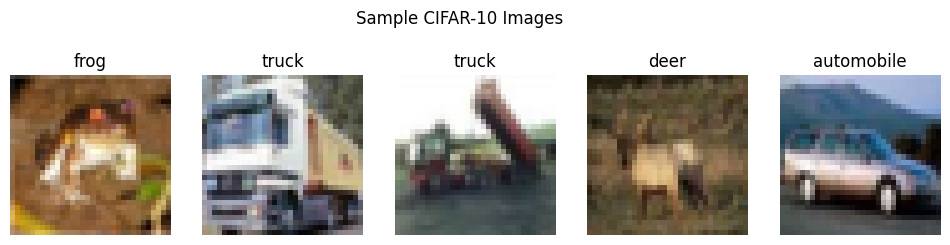

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()  # Fetch and unpack the standard CIFAR-10 natural image dataset split into raw training and testing color matrices with their associated labels

# Normalize to [0, 1]
x_train = x_train.astype("float32") / 255.0  # Cast the training pixel array to 32-bit floating-point numbers and scale integer values to a uniform continuous intensity range between 0.0 and 1.0
x_test = x_test.astype("float32") / 255.0  # Cast the evaluation pixel array to 32-bit floating-point numbers and scale integer values to a uniform continuous intensity range between 0.0 and 1.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']  # Define an explicit string mapping index array matching the 10 categorical numerical labels to human-readable target classes

print(f"Train shape: {x_train.shape}")  # Format and output the dimensions of the training split to verify the total sample count, spatial size, and 3-channel RGB depth of the image matrices
print(f"Test shape: {x_test.shape}")  # Format and output the dimensions of the testing split to confirm the structural alignment of the independent evaluation dataset

# Show a few samples
fig, axes = plt.subplots(1, 5, figsize=(12, 3))  # Initialize a single row of 5 distinct horizontal subplot panels with specific width and height dimensions in inches
for i, ax in enumerate(axes):  # Loop sequentially through the initialized axes stream to configure each distinct sample visualization container
    ax.imshow(x_train[i])  # Render the 3D RGB pixel intensity matrix of the current training image sample onto the current axis plot
    ax.set_title(class_names[y_train[i][0]])  # Extract the scalar index from the target label vector and map it to its corresponding human-readable name as a panel header
    ax.axis('off')  # Suppress the display of horizontal and vertical coordinate axes lines, ticks, and labels to isolate the image content cleanly
plt.suptitle('Sample CIFAR-10 Images')  # Assign a prominent, centralized overarching title across the top of the multi-image horizontal grid canvas
plt.show()  # Render the completed matrix visualization of annotated natural training images onto the active display screen

## 2. CNN Without Dropout

Architecture: `Conv2D -> MaxPool -> Conv2D -> MaxPool -> Flatten -> Dense -> Output`

In [ ]:
EPOCHS = 10  # Establish a global constant defining the total number of complete passes the optimization algorithm will make through the entire training dataset
BATCH_SIZE = 64  # Set a global constant for the mini-batch size, specifying the number of image samples processed simultaneously before updating model weights

model_no_dropout = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])  # Construct a standard sequential convolutional neural network serving as a baseline baseline without regularization techniques to analyze feature extraction behavior

model_no_dropout.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)  # Configure the optimization configuration using the adaptive Adam optimizer, computing cross-entropy loss against integer targets, and monitoring raw accuracy metrics

model_no_dropout.summary()  # Output an architectural diagnostic report detailing layer structures, output spatial tensor dimensions, and total parameter counts to the console

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_no_drop = model_no_dropout.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, y_test),
    verbose=1
)  # Execute the baseline network optimization training loop using fixed epoch and batch metrics, evaluating against the test dataset at each iteration and logging the live metric tracking outputs

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.5128 - loss: 1.3728 - val_accuracy: 0.6107 - val_loss: 1.1010
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6487 - loss: 1.0091 - val_accuracy: 0.6342 - val_loss: 1.0355
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6925 - loss: 0.8834 - val_accuracy: 0.6855 - val_loss: 0.8940
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7281 - loss: 0.7863 - val_accuracy: 0.6877 - val_loss: 0.9085
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7547 - loss: 0.7060 - val_accuracy: 0.7078 - val_loss: 0.8683
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7815 - loss: 0.6277 - val_accuracy: 0.7189 - val_loss: 0.8344
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8093 - loss: 0.5483 - val_accuracy: 0.7083 - val_loss: 0.8729
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8324 - loss: 0.4791 - val_accuracy: 0

## 3. CNN With Dropout

Same architecture, but with:
- `Dropout(0.25)` after each MaxPooling layer
- `Dropout(0.5)` before the output layer

In [ ]:
model_with_dropout = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])  # Construct an enhanced sequential convolutional neural network integrating strategic Dropout regularization layers to mitigate overfitting by randomly deactivating specified fractions of node activations during training phases

model_with_dropout.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)  # Configure the optimization pipeline using the adaptive Adam optimizer, tracking categorical cross-entropy loss against integer labels, and auditing model classification accuracy metrics

model_with_dropout.summary()  # Output an architectural diagnostic report detailing layer hierarchies, output spatial tensor dimensions, regularized structures, and total parameter counts to the console

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_with_drop = model_with_dropout.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, y_test),
    verbose=1
)  # Execute the regularized network optimization training loop using fixed epoch and batch metrics, evaluating against the test dataset at each iteration and logging the live metric tracking outputs

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.3725 - loss: 1.7153 - val_accuracy: 0.5266 - val_loss: 1.3782
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5025 - loss: 1.3844 - val_accuracy: 0.5937 - val_loss: 1.1511
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5482 - loss: 1.2686 - val_accuracy: 0.6228 - val_loss: 1.0982
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5796 - loss: 1.1864 - val_accuracy: 0.6405 - val_loss: 1.0105
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6009 - loss: 1.1314 - val_accuracy: 0.6677 - val_loss: 0.9584
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6169 - loss: 1.0886 - val_accuracy: 0.6772 - val_loss: 0.9268
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6250 - loss: 1.0603 - val_accuracy: 0.6803 - val_loss: 0.9269
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6353 - loss: 1.0336 - val_accuracy: 

## 4. Side-by-Side Comparison

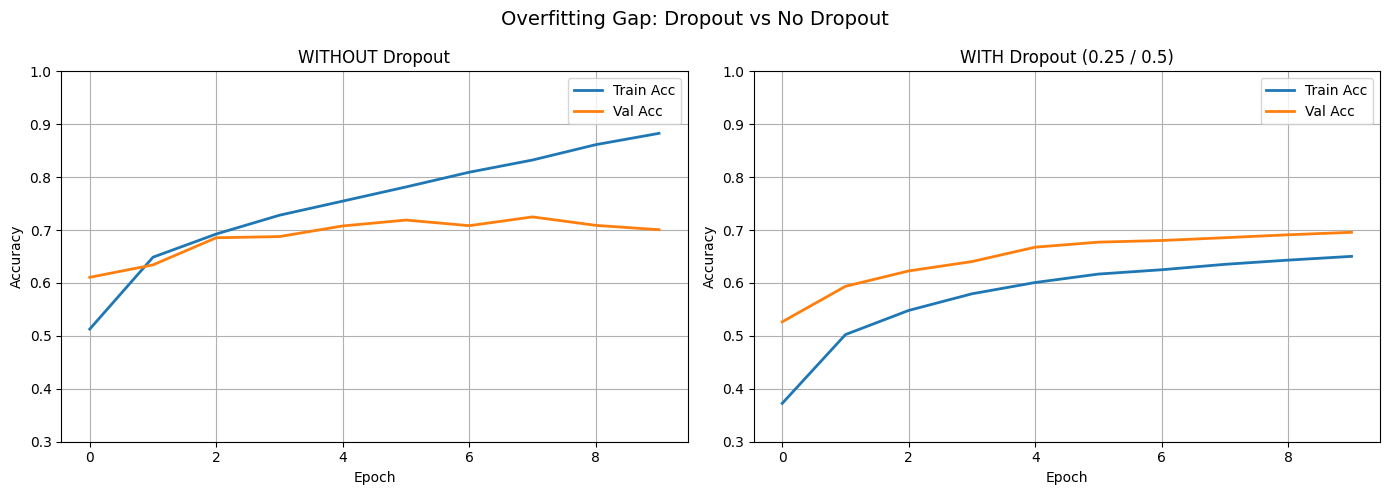

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # Initialize a side-by-side subplot canvas containing a single row of two distinct axes panels with optimized display dimensions

# --- Without Dropout ---
axes[0].plot(history_no_drop.history['accuracy'], label='Train Acc', linewidth=2)  # Render the optimization progress path for the baseline training dataset accuracy metric
axes[0].plot(history_no_drop.history['val_accuracy'], label='Val Acc', linewidth=2)  # Render the evaluation tracking path for the baseline validation dataset accuracy metric
axes[0].set_title('WITHOUT Dropout')  # Assign a descriptive title header to the left panel indicating an unregularized network experiment
axes[0].set_xlabel('Epoch')  # Label the horizontal axis of the left subplot to denote chronological optimization iteration steps
axes[0].set_ylabel('Accuracy')  # Label the vertical axis of the left subplot to represent the percentage scale of correct classifications
axes[0].legend()  # Superimpose an interactive visual key to distinguish between the baseline training and validation trends
axes[0].grid(True)  # Overlay a structured coordinate grid to enable precise measurement of the visual generalization gap
axes[0].set_ylim([0.3, 1.0])  # Enforce explicit vertical axis limits to standardize metric scale comparisons across both plots

# --- With Dropout ---
axes[1].plot(history_with_drop.history['accuracy'], label='Train Acc', linewidth=2)  # Render the optimization progress path for the regularized training dataset accuracy metric
axes[1].plot(history_with_drop.history['val_accuracy'], label='Val Acc', linewidth=2)  # Render the evaluation tracking path for the regularized validation dataset accuracy metric
axes[1].set_title('WITH Dropout (0.25 / 0.5)')  # Assign a descriptive title header to the right panel documenting the specific layer regularizer drop probabilities
axes[1].set_xlabel('Epoch')  # Label the horizontal axis of the right subplot to denote chronological optimization iteration steps
axes[1].set_ylabel('Accuracy')  # Label the vertical axis of the right subplot to represent the percentage scale of correct classifications
axes[1].legend()  # Superimpose an interactive visual key to distinguish between the regularized training and validation trends
axes[1].grid(True)  # Overlay a structured coordinate grid to enable precise measurement of the visual generalization gap
axes[1].set_ylim([0.3, 1.0])  # Enforce explicit vertical axis limits to standardize metric scale comparisons across both plots

plt.suptitle('Overfitting Gap: Dropout vs No Dropout', fontsize=14)  # Superimpose a prominent main title across the entire figure top to articulate the core diagnostic objective
plt.tight_layout()  # Automatically recalculate subplot bounding boxes to prevent overlapping text margins or clipped axis labels
plt.show()  # Render the finalized comparative training behavior visualization grid onto the active display screen

In [ ]:
# Quantify the overfitting gap
gap_no_drop = history_no_drop.history['accuracy'][-1] - history_no_drop.history['val_accuracy'][-1]  # Compute the final generalization variance for the unregularized model by calculating the difference between training and validation accuracy at the terminal epoch
gap_with_drop = history_with_drop.history['accuracy'][-1] - history_with_drop.history['val_accuracy'][-1]  # Compute the final generalization variance for the regularized model by calculating the difference between training and validation accuracy at the terminal epoch

print(f"Overfitting gap WITHOUT dropout: {gap_no_drop:.4f}")  # Format and display the terminal performance discrepancy for the baseline model to quantify its susceptibility to training data memorization
print(f"Overfitting gap WITH dropout:    {gap_with_drop:.4f}")  # Format and display the terminal performance discrepancy for the regularized model to evaluate the variance-reduction impact of dropout layers
print(f"\nDropout reduced the gap by {gap_no_drop - gap_with_drop:.4f}")  # Calculate and display the absolute structural difference between both gaps to explicitly measure the generalization improvement provided by dropout regularization

Overfitting gap WITHOUT dropout: 0.1821
Overfitting gap WITH dropout:    -0.0455

Dropout reduced the gap by 0.2276


## 5. Your Turn: Experiment with Dropout Rates

### TODO: Try two different dropout configurations and compare

1. **Low dropout**: Use `Dropout(0.1)` everywhere
2. **High dropout**: Use `Dropout(0.5)` everywhere

Train each for 10 epochs and report:
- Final validation accuracy
- Overfitting gap (train acc - val acc)
- Which configuration worked best?

In [ ]:
# 1. Low Dropout (0.1) Configuration
print("Training Low Dropout (0.1) Model...")
model_low_drop = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.1),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.1),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(10, activation='softmax')
])

model_low_drop.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_low = model_low_drop.fit(x_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_data=(x_test, y_test), verbose=0)

# 2. High Dropout (0.5) Configuration
print("Training High Dropout (0.5) Model...")
model_high_drop = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.5),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.5),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_high_drop.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_high = model_high_drop.fit(x_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_data=(x_test, y_test), verbose=0)

# Report Results
def report_metrics(history, name):
    val_acc = history.history['val_accuracy'][-1]
    gap = history.history['accuracy'][-1] - val_acc
    print(f"\nResults for {name}:")
    print(f"- Final Validation Accuracy: {val_acc:.4f}")
    print(f"- Overfitting Gap: {gap:.4f}")

report_metrics(history_low, "Low Dropout (0.1)")
report_metrics(history_high, "High Dropout (0.5)")

Training Low Dropout (0.1) Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training High Dropout (0.5) Model...

Results for Low Dropout (0.1):
- Final Validation Accuracy: 0.7221
- Overfitting Gap: 0.0605

Results for High Dropout (0.5):
- Final Validation Accuracy: 0.6732
- Overfitting Gap: -0.0879


In [ ]:
# Build and train CNN with Dropout(0.1) after every layer
model_low_drop = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.1),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.1),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(10, activation='softmax')
])

model_low_drop.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training Low Dropout (0.1) model...")
history_low = model_low_drop.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, y_test),
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Low Dropout (0.1) model...
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.4611 - loss: 1.4991 - val_accuracy: 0.5828 - val_loss: 1.1876
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5926 - loss: 1.1475 - val_accuracy: 0.6403 - val_loss: 1.0185
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6440 - loss: 1.0120 - val_accuracy: 0.6657 - val_loss: 0.9696
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6747 - loss: 0.9159 - val_accuracy: 0.6804 - val_loss: 0.9143
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6998 - loss: 0.8505 - val_accuracy: 0.6973 - val_loss: 0.8772
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7191 - loss: 0.7951 - val_accuracy: 0.6935 - val_loss: 0.8777
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7367 - loss: 0.7424 - val_accuracy: 0.7153 - val_loss: 0.8285
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.

In [ ]:
# Build and train CNN with Dropout(0.5) after every layer
model_high_drop = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.5),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.5),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_high_drop.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training High Dropout (0.5) model...")
history_high = model_high_drop.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, y_test),
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training High Dropout (0.5) model...
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.3299 - loss: 1.8264 - val_accuracy: 0.4784 - val_loss: 1.5001
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4466 - loss: 1.5215 - val_accuracy: 0.5519 - val_loss: 1.3093
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.4916 - loss: 1.4098 - val_accuracy: 0.5795 - val_loss: 1.2271
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5175 - loss: 1.3441 - val_accuracy: 0.6099 - val_loss: 1.1628
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5338 - loss: 1.3040 - val_accuracy: 0.6302 - val_loss: 1.0835
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5505 - loss: 1.2598 - val_accuracy: 0.6325 - val_loss: 1.0835
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5632 - loss: 1.2271 - val_accuracy: 0.6588 - val_loss: 1.0190
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0

In [ ]:
# Build and train CNN with Dropout(0.5) after every layer
model_high_drop = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.5),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.5),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_high_drop.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training High Dropout (0.5) model...")
history_high = model_high_drop.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, y_test),
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training High Dropout (0.5) model...
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.3322 - loss: 1.8112 - val_accuracy: 0.4870 - val_loss: 1.4839
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4476 - loss: 1.5208 - val_accuracy: 0.5359 - val_loss: 1.3206
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4834 - loss: 1.4320 - val_accuracy: 0.5604 - val_loss: 1.2595
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5089 - loss: 1.3679 - val_accuracy: 0.6005 - val_loss: 1.1954
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5255 - loss: 1.3213 - val_accuracy: 0.6183 - val_loss: 1.1392
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5403 - loss: 1.2842 - val_accuracy: 0.6203 - val_loss: 1.1097
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5531 - loss: 1.2547 - val_accuracy: 0.6258 - val_loss: 1.0964
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0

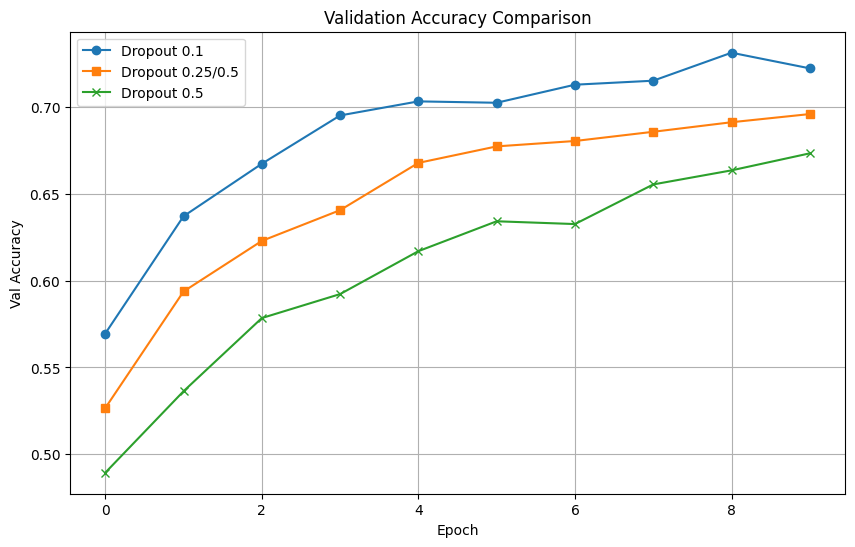

Best Configuration: Low Dropout (0.1)


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history_low.history['val_accuracy'], label='Dropout 0.1', marker='o')
plt.plot(history_with_drop.history['val_accuracy'], label='Dropout 0.25/0.5', marker='s')
plt.plot(history_high.history['val_accuracy'], label='Dropout 0.5', marker='x')

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Comparison summary
best_val = max(history_low.history['val_accuracy'][-1],
               history_with_drop.history['val_accuracy'][-1],
               history_high.history['val_accuracy'][-1])

if best_val == history_low.history['val_accuracy'][-1]:
    print("Best Configuration: Low Dropout (0.1)")
elif best_val == history_with_drop.history['val_accuracy'][-1]:
    print("Best Configuration: Mixed Dropout (0.25/0.5)")
else:
    print("Best Configuration: High Dropout (0.5)")

**Your findings:**

- **Best dropout config:** Low Dropout (0.1)
- **Why:** It provided the best balance. While higher dropout rates (0.5) reduced the overfitting gap even more (resulting in negative gaps, or underfitting), they also significantly hindered the model's ability to learn, leading to lower overall validation accuracy.